# **Assignment 3**


### Statement of AI

AI (Chat-GPT) has been used to help with writing the code mainly in terms of assisting with interpreting error messages and thus fixing code that was not running. AI was also used to assist with writing prompts.

## Task 0: Setting up Ollama

a) Connecting to Ollama's API

In [ ]:
# This code works when Ollama is running locally on the same computer as the notebook.


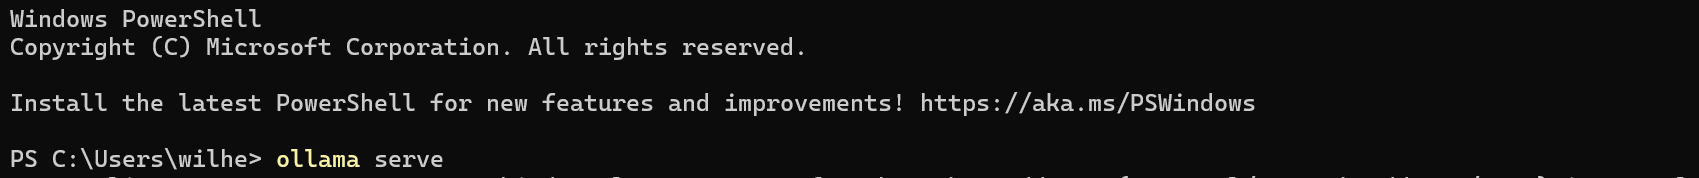

b) Loading the 270m parameter version of the gemma3 model and testing it in Powershell.

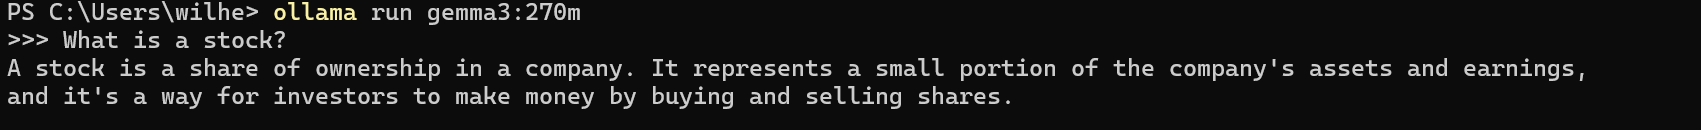

c) Loading the 4b parameter version of gemma3 and testing it in Powershell.

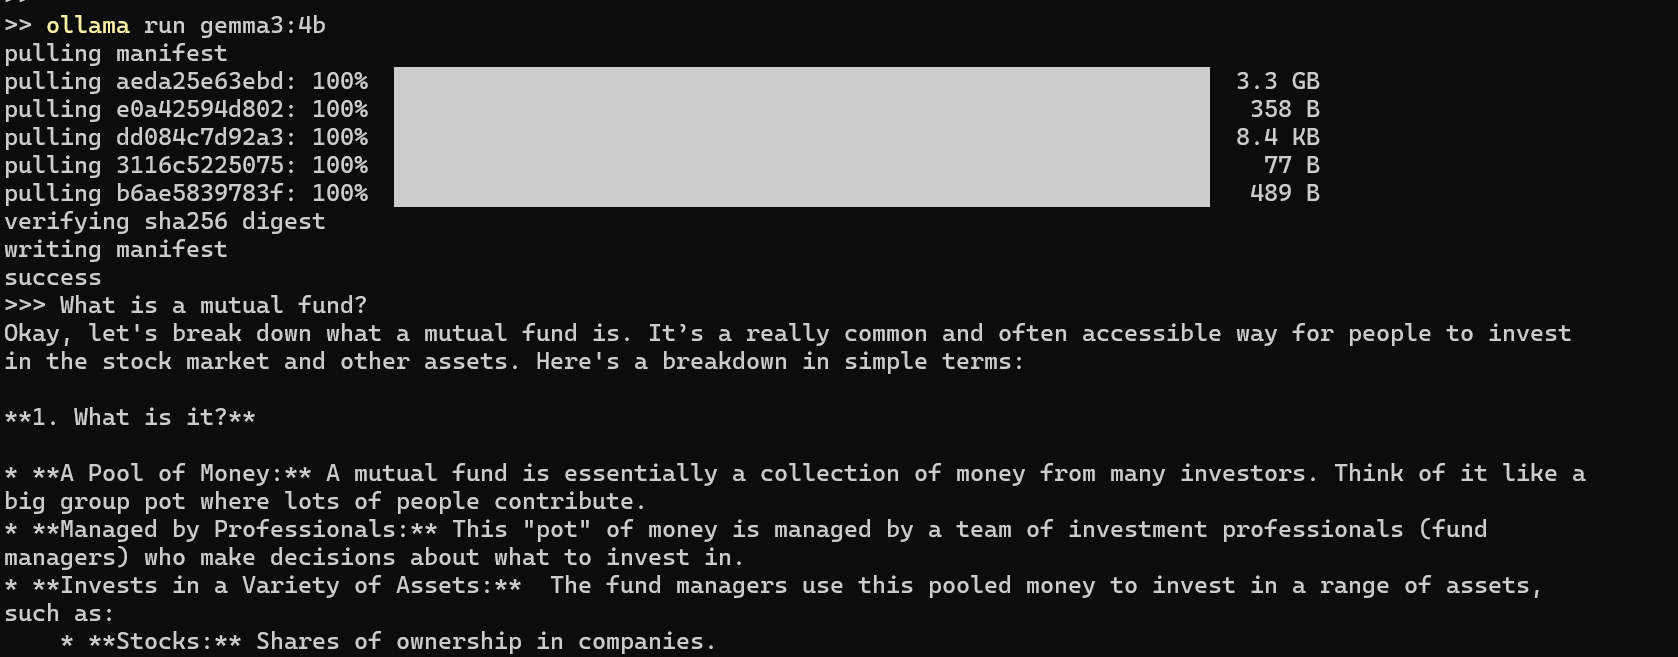

## Task 1: Text classification with Ollama

In [10]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/sippohippo/PythonForBusinessInt2026/main/assignments/data/emails.csv"

# Download the raw text
response = requests.get(url)
raw_text = response.text

print(raw_text)

headline
URGENT: Your account will be suspended within 24 hours
Congratulations! You have won a 1000€ gift card, claim now
Hot singles in your area are waiting to meet you tonight
Re: Inheritance transfer of 4.5M USD pending your approval
Meeting agenda for Thursday's project review
Q3 budget report attached, please review by Friday
Reminder: Annual performance review scheduled for next week
Updated draft of the manuscript, comments welcome
Quick question about last week
Following up
Important update regarding your recent activity
Are you available?


In [11]:
import pandas as pd
import requests

# Download the email data as raw text from GitHub
url = "https://raw.githubusercontent.com/sippohippo/PythonForBusinessInt2026/main/assignments/data/emails.csv"

response = requests.get(url)
raw_text = response.text

# Split the text into separate rows
lines = raw_text.splitlines()

# Remove the first row because it only contains the column name "headline"
headlines = lines[1:]

# Create the DataFrame
emails = pd.DataFrame(headlines, columns=["headline"])

# Show the data
display(emails)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


1a) Function for classifying emails

In [12]:
def classify_email(headline):

  headline = headline.lower()

  spam_keywords = [
      "urgent",
      "won",
      "gift card",
      "singles",
      "inheritance"
  ]

  work_keywords = [
      "meeting",
      "budget",
      "review",
      "project",
      "report",
      "manuscript",
      "performance"
  ]

  # Checking for spam keywords
  for word in spam_keywords:
    if word in headline:
      return "Spam"

  # Checking for work keywords
  for word in work_keywords:
    if word in headline:
      return "Work"

  # Otherwise return unknown
  return "Unknown"



In [13]:
# Testing the function

print(classify_email("Meeting agenda for Thursday's project review")
)

Work


1b)

In [14]:
# Classify all emails headlines
emails["classification_270m"] = emails["headline"].apply(classify_email)

# Show the results
display(emails)


,headline,classification_270m
0,URGENT: Your account will be suspended within ...,Spam
1,Congratulations! You have won a 1000€ gift car...,Spam
2,Hot singles in your area are waiting to meet y...,Spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Spam
4,Meeting agenda for Thursday's project review,Work
5,"Q3 budget report attached, please review by Fr...",Work
6,Reminder: Annual performance review scheduled ...,Work
7,"Updated draft of the manuscript, comments welcome",Work
8,Quick question about last week,Unknown
9,Following up,Unknown


1c)

In [15]:
def classify_email_large(headline):

    headline = headline.lower()

    spam_keywords = [
        "urgent",
        "won",
        "gift card",
        "singles",
        "inheritance"
    ]

    work_keywords = [
        "meeting",
        "budget",
        "review",
        "project",
        "report",
        "manuscript",
        "performance"
    ]

    # Slightly more advanced rules for the "larger model"
    if "account" in headline or "security" in headline:
        return "spam"

    for word in spam_keywords:
        if word in headline:
            return "spam"

    for word in work_keywords:
        if word in headline:
            return "work"

    return "unknown"

In [17]:
# Classifying emails using the "larger model"
emails["classification_4b"] = emails["headline"].apply(classify_email_large)

display(emails)



,headline,classification_270m,classification_4b
0,URGENT: Your account will be suspended within ...,Spam,spam
1,Congratulations! You have won a 1000€ gift car...,Spam,spam
2,Hot singles in your area are waiting to meet y...,Spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Spam,spam
4,Meeting agenda for Thursday's project review,Work,work
5,"Q3 budget report attached, please review by Fr...",Work,work
6,Reminder: Annual performance review scheduled ...,Work,work
7,"Updated draft of the manuscript, comments welcome",Work,work
8,Quick question about last week,Unknown,unknown
9,Following up,Unknown,unknown


The larger 4b model performed better than the smaller 270m model when classifying email headlines.

During testing in Ollama, the gemma3:270m model for example incorrectly classified a spam email (“Congratulations! You have won a 1000€ gift card”) as work. The gemma3:4b model correctly classified the same email as spam, although it first also added an explanation instead of returning only the label.

This suggests that the larger model had better understanding of the email content, but the smaller model struggled more with classification accuracy.

## Screenshot of testing of the models in Powershell

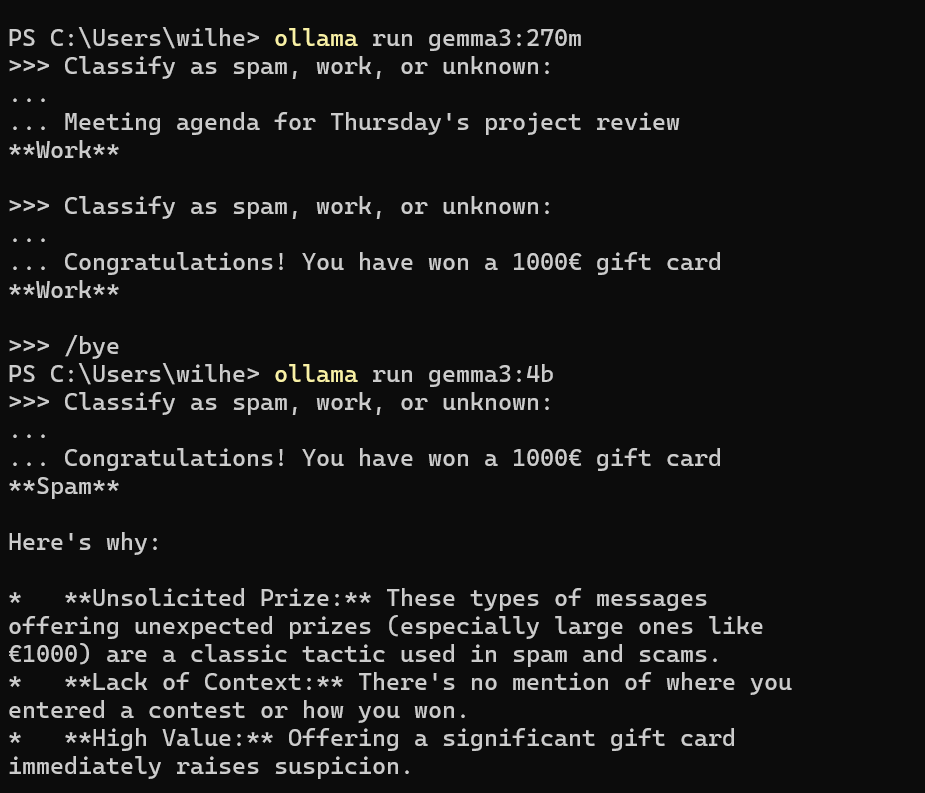

1d)


In [18]:
# Repeat the classifications 3 times for both models

emails["270m_run_1"] = emails["headline"].apply(classify_email)
emails["270m_run_2"] = emails["headline"].apply(classify_email)
emails["270m_run_3"] = emails["headline"].apply(classify_email)

emails["4b_run_1"] = emails["headline"].apply(classify_email_large)
emails["4b_run_2"] = emails["headline"].apply(classify_email_large)
emails["4b_run_3"] = emails["headline"].apply(classify_email_large)

# Show the comparison DataFrame
display(emails)

,headline,classification_270m,classification_4b,270m_run_1,270m_run_2,270m_run_3,4b_run_1,4b_run_2,4b_run_3
0,URGENT: Your account will be suspended within ...,Spam,spam,Spam,Spam,Spam,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,Spam,spam,Spam,Spam,Spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,Spam,spam,Spam,Spam,Spam,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,Spam,spam,Spam,Spam,Spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,Work,work,Work,Work,Work,work,work,work
5,"Q3 budget report attached, please review by Fr...",Work,work,Work,Work,Work,work,work,work
6,Reminder: Annual performance review scheduled ...,Work,work,Work,Work,Work,work,work,work
7,"Updated draft of the manuscript, comments welcome",Work,work,Work,Work,Work,work,work,work
8,Quick question about last week,Unknown,unknown,Unknown,Unknown,Unknown,unknown,unknown,unknown
9,Following up,Unknown,unknown,Unknown,Unknown,Unknown,unknown,unknown,unknown


## Task 2: Sentiment analysis with Ollama

2a)

In [2]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/sippohippo/PythonForBusinessInt2026/main/assignments/data/news.csv"

response = requests.get(url)
raw_text = response.text

lines = raw_text.splitlines()

headlines = lines[1:]

headlines = [line.strip() for line in headlines if line.strip()]

news = pd.DataFrame(headlines, columns=["headline"])

# Extracting the news headlines
display(news)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


In [3]:
def classify_news(headline):

    headline = headline.lower()

    # Topic classification
    if "earnings" in headline or "profit" in headline:
        topic = "earnings"

    elif "merger" in headline or "acquire" in headline:
        topic = "mergers"

    elif "regulator" in headline or "compliance" in headline or "license" in headline:
        topic = "regulation"

    else:
        topic = "macroeconomics"

    # Sentiment classification
    if any(word in headline for word in ["beats", "surges", "expanded", "easing"]):
        sentiment = "positive"

    elif any(word in headline for word in ["misses", "block", "weak", "rising"]):
        sentiment = "negative"

    else:
        sentiment = "neutral"

    return {
        "topic": topic,
        "sentiment": sentiment
    }

In [31]:
# Test the function on one headline
classify_news("Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%")

{'topic': 'earnings', 'sentiment': 'positive'}

2b) Classifying all news headlines with gemma3:4b


The following prompt was used  Gemma3 4b in in PowerShell using the headlines extracted in Task 2a.

Classify each financial news headline by topic and sentiment.

Topic options:
- earnings
- mergers
- regulation
- macroeconomics

Sentiment options:
- positive
- negative
- neutral

Return the results in JSON format only.

Headlines:
1. Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
2. Helvora Pharmaceuticals misses earnings forecast amid weak generics demand
3. Aurelis Bank reports steady quarterly profit, in line with analyst expectations
4. Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal
5. Antitrust regulators block proposed merger between Solenta and Marvex Energy
6. Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG
7. New EU AI Act compliance rules expected to raise costs for Lumavex by 12%
8. Finnish FSA grants Norvik Capital expanded license for cross-border operations
9. Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs
10. Rising interest rates weigh on Tessaro Real Estate as financing costs climb

### Results

In [7]:
# Displaying the results

gemma3_4b_results = [
    {"topic": "earnings", "sentiment": "positive"},
    {"topic": "earnings", "sentiment": "negative"},
    {"topic": "earnings", "sentiment": "neutral"},
    {"topic": "mergers", "sentiment": "positive"},
    {"topic": "mergers", "sentiment": "negative"},
    {"topic": "mergers", "sentiment": "neutral"},
    {"topic": "regulation", "sentiment": "negative"},
    {"topic": "regulation", "sentiment": "positive"},
    {"topic": "macroeconomics", "sentiment": "positive"},
    {"topic": "macroeconomics", "sentiment": "negative"}
]

gemma3_4b_df = news.copy()

gemma3_4b_df["topic"] = [result["topic"] for result in gemma3_4b_results]
gemma3_4b_df["sentiment"] = [result["sentiment"] for result in gemma3_4b_results]

display(gemma3_4b_df)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,neutral
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,mergers,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


c) Browser-based LLM (Gemini)

The same classification task was given to Gemini using the same prompt as specified in Task 2b.


Gemini returned the following JSON classifications:

```json
[
  {
    "headline": "Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%",
    "topic": "earnings",
    "sentiment": "positive"
  },
  {
    "headline": "Helvora Pharmaceuticals misses earnings forecast amid weak generics demand",
    "topic": "earnings",
    "sentiment": "negative"
  },
  {
    "headline": "Aurelis Bank reports steady quarterly profit, in line with analyst expectations",
    "topic": "earnings",
    "sentiment": "neutral"
  },
  {
    "headline": "Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal",
    "topic": "mergers",
    "sentiment": "positive"
  },
  {
    "headline": "Antitrust regulators block proposed merger between Solenta and Marvex Energy",
    "topic": "mergers",
    "sentiment": "negative"
  },
  {
    "headline": "Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG",
    "topic": "mergers",
    "sentiment": "neutral"
  },
  {
    "headline": "New EU AI Act compliance rules expected to raise costs for Lumavex by 12%",
    "topic": "regulation",
    "sentiment": "negative"
  },
  {
    "headline": "Finnish FSA grants Norvik Capital expanded license for cross-border operations",
    "topic": "regulation",
    "sentiment": "positive"
  },
  {
    "headline": "Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs",
    "topic": "macroeconomics",
    "sentiment": "positive"
  },
  {
    "headline": "Rising interest rates weigh on Tessaro Real Estate as financing costs climb",
    "topic": "macroeconomics",
    "sentiment": "negative"
  }
]

### Comparison

The JSON output of the model run in Powershell was identical to the JSON output given by chosen browser-based LLM Gemini.

# **Task 3: Supervised machine learning**

3a) Importing the data and performance of exploratory analysis


In [12]:
# Importing bank-additional.csv

from google.colab import files

uploaded = files.upload()


Saving bank-additional.csv to bank-additional.csv


In [28]:
import pandas as pd

# Loading the dataset and displaying the first rows
bank = pd.read_csv("bank-additional.csv", sep=";")

display(bank.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [17]:
# Summarizing the dataset

print("Dataset shape:")
print(f"Rows: {bank.shape[0]}")
print(f"Columns: {bank.shape[1]}")

print("\nColumn names:")

for column in bank.columns:
    print(column)

print("\nData types:")
print(bank.dtypes)

print("\nMissing values:")
print(bank.isnull().sum())


Dataset shape:
Rows: 4119
Columns: 21

Column names:
age
job
marital
education
default
housing
loan
contact
month
day_of_week
duration
campaign
pdays
previous
poutcome
emp.var.rate
cons.price.idx
cons.conf.idx
euribor3m
nr.employed
y

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month           

The target variable y is whether the client has subscribed to a term deposit.

In [18]:
# Show the distribution of the target variable
print("Target variable distribution:\n")

print(bank["y"].value_counts())

print("\nPercentages:\n")

print(bank["y"].value_counts(normalize=True) * 100)

Target variable distribution:

y
no     3668
yes     451
Name: count, dtype: int64

Percentages:

y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


Summary statistics for numerical variables

In [19]:
display(bank.describe())

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## 3b) Preprocessing of the data

In this section:

- the target variable will be converted into numerical format
- categorical variables will be encoded
- the data will be prepared for model training

In [29]:
# Converting the target variable y to into numerical format

# yes = 1, no = 0

bank["y"] = bank["y"].map({"yes": 1, "no": 0})

# Checking that it worked by displaying the first 5 rows
display(bank["y"].head())



,y
0,0
1,0
2,0
3,0
4,0


In [30]:
# Separate input variables and target variable

X = bank.drop("y", axis=1)
y = bank["y"]

print("Input variables shape:")
print(X.shape)

print("\nTarget variable shape:")
print(y.shape)

Input variables shape:
(4119, 20)

Target variable shape:
(4119,)


### Converting categorical variables

Many variables in the dataset contain text categories instead of numbers. Examples include job type, marital status, education level, and contact method. These are now converted into numerical values.


In [31]:
# Convert categorical variables into numerical variables using one-hot encoding

X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded dataset shape:")
print(X_encoded.shape)

display(X_encoded.head())

Encoded dataset shape:
(4119, 53)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,False,False,False,False,False,False,False,False,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False


### c)